In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
df.drop("RowNumber", axis = 1,inplace = True)

In [8]:
df["CustomerId"].corr(df["Exited"])

np.float64(-0.00624798663781877)

In [9]:
numeric_only = df.select_dtypes(["int64", "float64"])

In [10]:
for col in numeric_only:
    print(f"The correlation of Customer Id with {col} : {df["CustomerId"].corr(df[col])}")

The correlation of Customer Id with CustomerId : 1.0
The correlation of Customer Id with CreditScore : 0.00530790060441153
The correlation of Customer Id with Age : 0.009496867199704415
The correlation of Customer Id with Tenure : -0.014882553918481556
The correlation of Customer Id with Balance : -0.012418700275200131
The correlation of Customer Id with NumOfProducts : 0.016971877134926334
The correlation of Customer Id with HasCrCard : -0.014025130325571929
The correlation of Customer Id with IsActiveMember : 0.0016649648401705166
The correlation of Customer Id with EstimatedSalary : 0.015270680744754435
The correlation of Customer Id with Exited : -0.00624798663781877


In [11]:
df.drop("CustomerId", axis = 1, inplace = True)

In [12]:
import matplotlib.pyplot as plt

In [13]:
import seaborn as sns

In [14]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

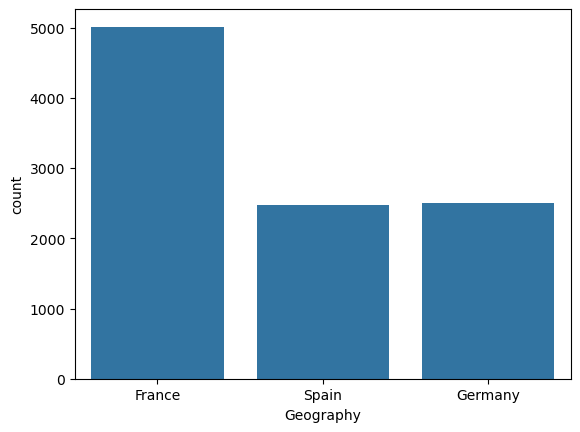

In [15]:
sns.countplot(x = "Geography" ,data = df)
plt.show()

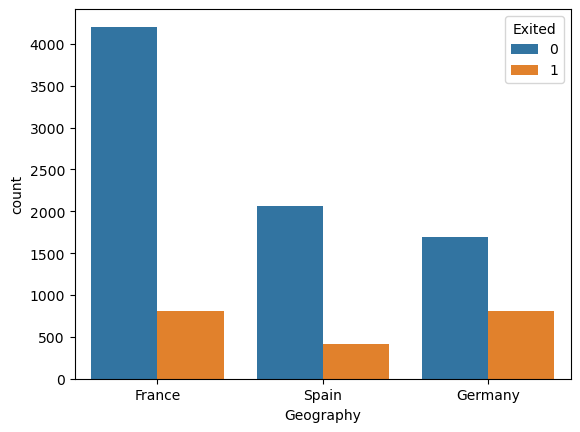

In [16]:
sns.countplot(x = "Geography", hue = "Exited",data = df)
plt.show()

In [17]:
df.drop("Surname", axis = 1, inplace = True)

In [18]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [20]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[df["Balance"] == 0].shape

(3617, 11)

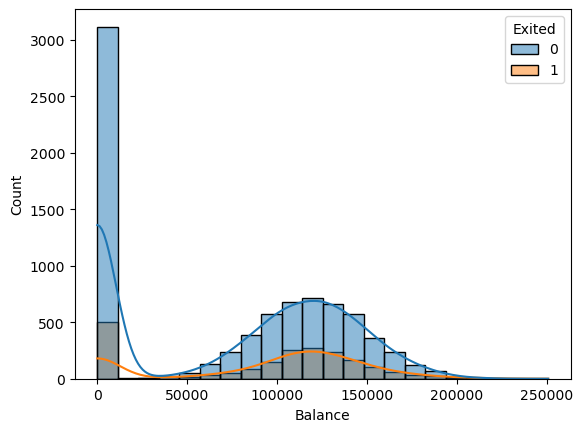

In [23]:
sns.histplot(x = "Balance", hue = "Exited",data = df, kde = True)
plt.show()

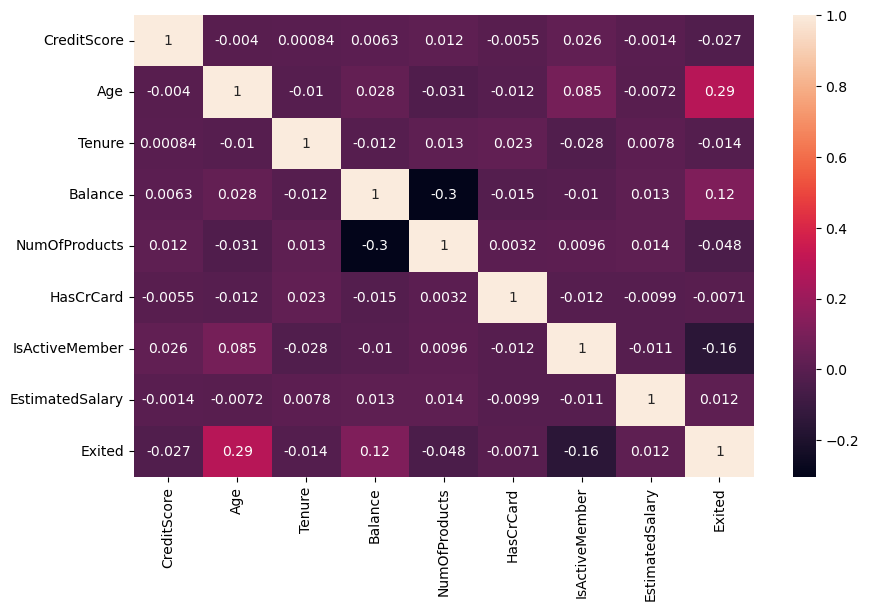

In [24]:
plt.figure(figsize = (10, 6))
sns.heatmap(
    df.corr(numeric_only = True),
    annot = True
)
plt.show()

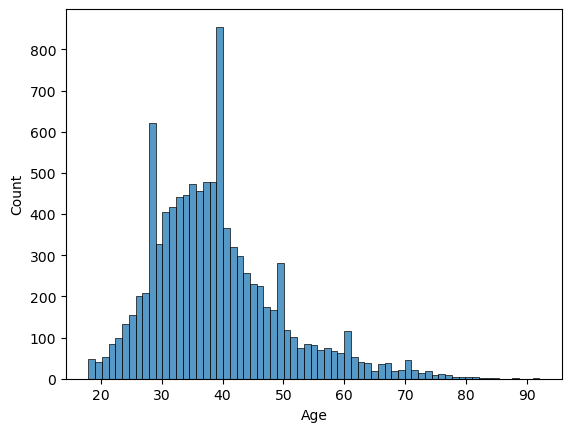

In [25]:
sns.histplot(x = "Age", data = df)
plt.show()

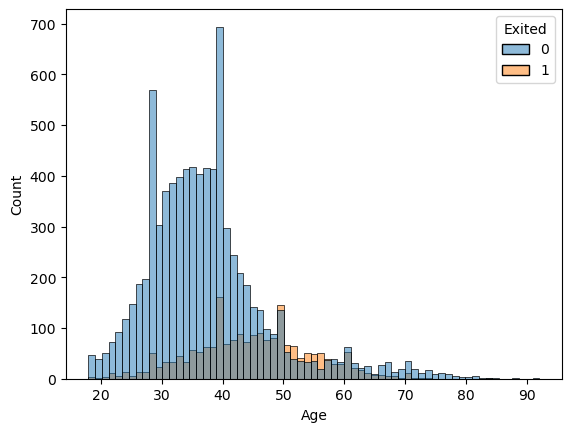

In [26]:
sns.histplot(x = "Age",hue = "Exited", data = df)
plt.show()

In [27]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [28]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [29]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,Female,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,False,True


In [30]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [31]:
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

In [32]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [33]:
df.dtypes

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object

In [34]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance","EstimatedSalary"]

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [37]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,1,0,1,0.216534,0,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,3,1,0,0.240687,1,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,0,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0,False,True,False


In [38]:
df["NumOfProducts"].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [39]:
X = df.drop("Exited", axis = 1)

In [40]:
y = df["Exited"]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
X_train.shape

(8000, 11)

In [44]:
y_train.shape

(8000,)

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression()

In [47]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

In [50]:
accuracy_score(y_test, y_pred)* 100


81.15

In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
confusion_matrix(y_test, y_pred)

array([[1544,   63],
       [ 314,   79]])